# 3.3.2 DIN 候选感知排序

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

为什么同一位用户面对相机和跑鞋时应该激活不同历史？如何让用户表示依赖当前候选？

## Setup

本 Notebook 的默认真实数据是 **KuaiRand-Pure：真实短视频曝光、点击、长播与多反馈序列**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。

**主要资料：** [Zhou et al., 2018, DIN](https://arxiv.org/abs/1706.06978)

In [1]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.environ.setdefault("RECSYS_PROFILE", "smoke")
PROFILE = os.environ["RECSYS_PROFILE"]
from recsys_lab.data import (load_movielens, movielens_provenance, load_amazon_2023,
                             amazon_provenance, load_kuairand, kuairand_provenance)
DATASET_KEY = "kuairand"
if DATASET_KEY == "movielens":
    real_ratings, real_movies = load_movielens()
    real_interactions = real_ratings
    REAL_DATASET = movielens_provenance(real_ratings)
elif DATASET_KEY == "amazon-2023":
    real_ratings = load_amazon_2023()
    real_interactions, real_movies = real_ratings, None
    REAL_DATASET = amazon_provenance(real_ratings)
else:
    real_interactions, real_movies = load_kuairand()
    real_ratings = real_interactions
    REAL_DATASET = kuairand_provenance(real_interactions)
print({"profile": PROFILE, "root": str(ROOT), "real_dataset": REAL_DATASET})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'root': '/workspace', 'real_dataset': {'dataset': 'KuaiRand-Pure (Kuaishou, CIKM 2022)', 'source': 'https://zenodo.org/records/10439422/files/KuaiRand-Pure.tar.gz', 'source_sha256': 'c814bf6f3624c0cfae83c57de3df26b2ed206e5c57bab4c4dcbfabbabe20cbf0', 'license_file': '/workspace/data/kuairand-pure/LICENSE', 'slice_rule': 'top 256 users by standard-feed interaction count; ties by user_id; all standard and random-policy rows for those users retained', 'rows_used': 39098, 'users_used': 128, 'items_used': 2500, 'time_min_utc': '2022-04-09T04:17:39+00:00', 'time_max_utc': '2022-05-08T15:50:58+00:00', 'targets': 'observed is_click, long_view, is_like and other feed feedback', 'randomly_fabricated_rows': 0}}


## 学习地图

1. 从原始论文理解系统约束；
2. 用可手算数字读懂公式和形状；
3. 检查数据、切分与标签；
4. 使用工业框架模型类训练；
5. 分开验证训练、推理和测试；
6. 用实际输出讨论失败边界。

**本节问题：** 为什么同一位用户面对相机和跑鞋时应该激活不同历史？如何让用户表示依赖当前候选？

**先修知识：** 3.0 的向量、概率与损失函数。第一次阅读无需推导梯度，只要能解释输入、输出和形状。

## Paper & Context

DIN 不再先把历史压成与候选无关的固定向量，而用 activation unit 比较每条历史与目标商品。贡献是 target-aware representation；代价是每个候选都要重新读取历史。

**来源：** [Zhou et al., 2018, DIN](https://arxiv.org/abs/1706.06978)

请区分三层证据：论文中的离线实验、本 Notebook 验证的代码链路、生产系统尚需验证的在线收益。三者不能互相替代。

## Model Structure & Formula Walkthrough


### 结构：候选先提问，历史再回答

每条历史 $e_j$ 与目标 $e_t$ 组成 $[e_j,e_t,e_j-e_t,e_j\odot e_t]$。小型网络输出相关分数

$$a_j=g(e_j,e_t,e_j-e_t,e_j\odot e_t),\qquad v=\sum_j\alpha_je_j.$$

这里 $e_j-e_t$ 表示两者差异，$e_j\odot e_t$ 表示逐维共同激活。实现可对 $a_j$ 做 softmax 得到和为 1 的 $\alpha_j$；原论文也强调权重不必被解释为概率。兴趣向量 $v$ 与候选、用户和上下文拼接，经 MLP 得到 logit，再用 Sigmoid 与 BCE 训练。张量从历史 $[B,L,d]$ 经过逐位置打分变成 $[B,L]$ 权重，最终压缩为 $[B,d]$。

### 公式到代码

`run_din` 严格在当前曝光之前构造历史；Torch-RecHub DIN 的 ActivationUnit 对每个候选重新计算权重，所以代码同时展示 mask 与序列长度。

阅读源码时按“张量形状 → 前向计算 → score → loss → metric”五步追踪，不需要一次读完整个工程文件。

## Math by Hand

注意力分数 $a_j=g(e_j,e_t,e_j-e_t,e_j\odot e_t)$，用户兴趣为 $v=\sum_j a_je_j$。候选像问题，历史像资料：先给相关资料更高权重，再做加权平均。权重是针对当前候选临时计算的。

下面用 NumPy/Matplotlib 验证直觉。二维图只是教学投影，工业 embedding 虽有更多维，计算规则相同。

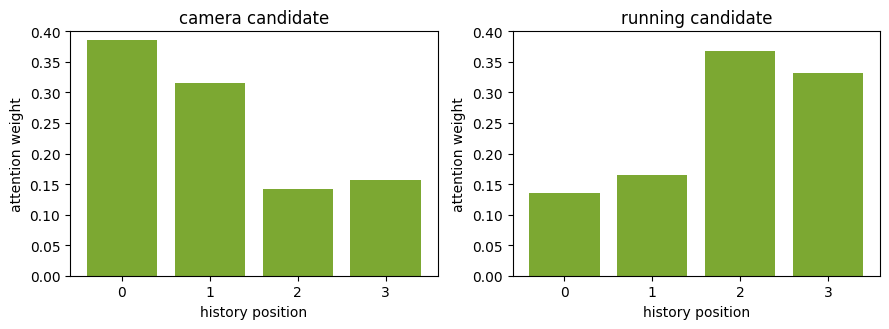

same history, different candidate -> different weights


In [2]:
import numpy as np, matplotlib.pyplot as plt
history=np.array([[1.,0.],[.8,.2],[0.,1.],[.1,.9]]); targets=[np.array([1.,0.]),np.array([0.,1.])]
fig,axes=plt.subplots(1,2,figsize=(9,3.4))
for ax,target,name in zip(axes,targets,['camera candidate','running candidate']):
    raw=history@target; weight=np.exp(raw)/np.exp(raw).sum(); ax.bar(range(4),weight,color='#7ca832')
    ax.set(ylim=(0,.4),title=name,xlabel='history position',ylabel='attention weight')
plt.tight_layout(); plt.show(); print('same history, different candidate -> different weights')

## Data

KuaiRand-Pure 的真实 feed impression：候选是当前视频，历史只含此前真实点击，标签直接读取 `is_click`；未点击曝光进入 observed negative history。

**防泄漏清单：**按时间切分；item 映射只表达已知目录，不读取测试标签；低评分或未点击负反馈均来自数据中的已观察行；序列只看预测时刻以前；测试集只在最后评价。CPU 档使用真实数据的确定性子集，**不是统一 benchmark 成绩**。

## Model & Framework

实际使用 torch_rechub.models.ranking.DIN，调用 SequenceFeature、ActivationUnit 与 Dice MLP；full profile 配置序列截断、缓存和候选批处理。

smoke 档强调模型类、张量契约和指标链路真实可运行；full 档应替换原始数据、分布式配置、索引/服务和资源预算，而不是只增加 epoch。

In [3]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from importlib import import_module
from recsys_lab.runtime import save_records

# 算法实现就在当前章节目录，不再通过公共模块隐藏。
chapter_train = import_module("chapter_code.3_3_2_din.train")
run_din = chapter_train.run_din

print("实际执行函数源码（包含数据、训练、推理和测试）：")
print(inspect.getsource(run_din))

实际执行函数源码（包含数据、训练、推理和测试）：
def run_din(epochs: int = 26) -> dict: return _run_sequence_ranker("din", epochs)



## Train & Inference

下一格实际执行完整 smoke：固定 seed、构造数据、实例化模型、训练、切换到推理路径并计算测试指标。

In [4]:
result = run_din()
print({'framework': result['framework'], 'dataset': result.get('dataset', {})})
print('inference contract:', '对每个候选计算目标感知 attention，再拼接上下文打分；候选多时需缩短历史、缓存 embedding 或先预排。')
assert np.isfinite(result['loss_curve']).all()
print('loss:', round(result['loss_curve'][0],4), '→', round(result['loss_curve'][-1],4))

{'framework': 'torch_rechub.models.ranking.DIN', 'dataset': {'dataset': 'KuaiRand-Pure (Kuaishou, CIKM 2022)', 'source': 'https://zenodo.org/records/10439422/files/KuaiRand-Pure.tar.gz', 'source_sha256': 'c814bf6f3624c0cfae83c57de3df26b2ed206e5c57bab4c4dcbfabbabe20cbf0', 'license_file': '/workspace/data/kuairand-pure/LICENSE', 'slice_rule': 'top 256 users by standard-feed interaction count; ties by user_id; all standard and random-policy rows for those users retained', 'rows_used': 29602, 'users_used': 96, 'items_used': 2200, 'time_min_utc': '2022-04-09T04:29:16+00:00', 'time_max_utc': '2022-05-08T15:50:58+00:00', 'targets': 'observed is_click, long_view, is_like and other feed feedback', 'randomly_fabricated_rows': 0, 'rows': 2600, 'sequence_length': 20, 'label': 'observed KuaiRand is_click', 'negative_history': 'observed skipped impressions', 'time_ordered': True}}
inference contract: 对每个候选计算目标感知 attention，再拼接上下文打分；候选多时需缩短历史、缓存 embedding 或先预排。
loss: 0.6525 → 0.0472


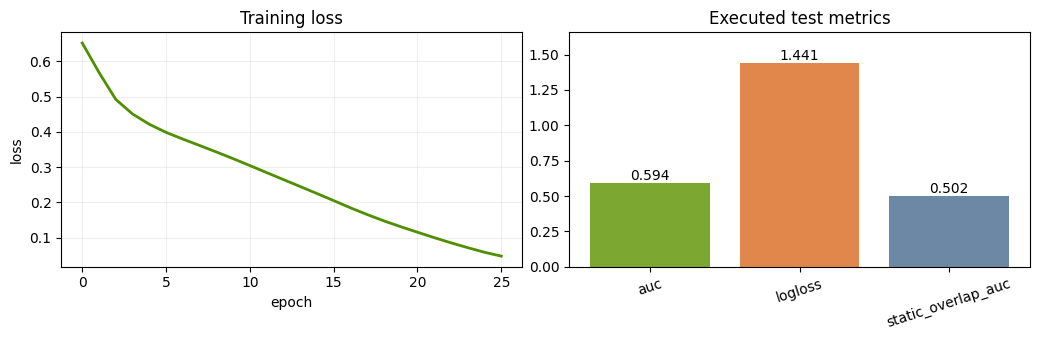

,value
auc,0.593823
logloss,1.441114
static_overlap_auc,0.501923


In [5]:
fig,axes=plt.subplots(1,2,figsize=(10.5,3.5))
axes[0].plot(result['loss_curve'],color='#4f8f00',lw=2); axes[0].set(title='Training loss',xlabel='epoch',ylabel='loss'); axes[0].grid(alpha=.2)
metrics={'auc': result['auc'], 'logloss': result['logloss'], 'static_overlap_auc': result['static_overlap_auc']}
axes[1].bar(range(len(metrics)),list(metrics.values()),color=['#7ca832','#e1874b','#6d88a4'][:len(metrics)])
axes[1].set_xticks(range(len(metrics)),list(metrics),rotation=18); axes[1].set(title='Executed test metrics',ylim=(0,max(1.0,max(metrics.values())*1.15)))
for index,value in enumerate(metrics.values()): axes[1].text(index,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show(); display(pd.Series(metrics,name='value').to_frame())

## Test & Results Discussion

In [6]:
display(Markdown(f'''### 本次已执行结果

- 主指标 auc = **{result['auc']:.4f}**。
- 辅助指标 logloss = **{result['logloss']:.4f}**。
- 对照指标 static_overlap_auc = **{result['static_overlap_auc']:.4f}**。
- 训练损失从 **{result['loss_curve'][0]:.4f}** 降到 **{result['loss_curve'][-1]:.4f}**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 真实小数据上静态基线可能更高；这正说明必须设置诚实 baseline，模型复杂度本身不是收益。

### 工业边界

对每个候选计算目标感知 attention，再拼接上下文打分；候选多时需缩短历史、缓存 embedding 或先预排。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。
'''))

### 本次已执行结果

- 主指标 auc = **0.5938**。
- 辅助指标 logloss = **1.4411**。
- 对照指标 static_overlap_auc = **0.5019**。
- 训练损失从 **0.6525** 降到 **0.0472**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 真实小数据上静态基线可能更高；这正说明必须设置诚实 baseline，模型复杂度本身不是收益。

### 工业边界

对每个候选计算目标感知 attention，再拼接上下文打分；候选多时需缩短历史、缓存 embedding 或先预排。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。


In [7]:
record={
    'algorithm': 'DIN 候选感知排序',
    'primary_metric': 'auc', 'primary_value': float(result['auc']),
    'secondary_metric': 'logloss', 'secondary_value': float(result['logloss']),
    'baseline_metric': 'static_overlap_auc',
    'baseline_value': float(result['static_overlap_auc']) if True else None,
    'framework': result['framework'], 'source_notebook': '3_3_2_din',
    'dataset': result['dataset']['dataset'],
    'randomly_fabricated_rows': int(result['dataset']['randomly_fabricated_rows'])
}
path=save_records('chapter_3_3','3_3_2_din',[record]); print('saved:',path.relative_to(ROOT))

saved: results/chapter_3_3/3_3_2_din.json


## Checks

自动断言用于防止数据、训练和指标链路静默失效，不是效果证明。

In [8]:
assert result['loss_curve'][-1] < result['loss_curve'][0]
assert 0 <= float(result['auc']) <= 1
assert np.isfinite(float(result['logloss']))
print('PASS：数据、训练、推理、测试和结果产物均已验证。')

PASS：数据、训练、推理、测试和结果产物均已验证。


## Next Steps

1. 换成对应公开数据的完整时间切分；2. 增加强 baseline 与消融；3. 记录效果、延迟和成本；4. 映射到 TorchEasyRec/官方 full profile；5. 只在相同候选与数据口径下比较。